In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


2.5.1+cu121
True
NVIDIA GeForce RTX 2060


In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms.v2 as transforms
from torchvision import datasets
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.models import vgg16
from torchvision.models import VGG16_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Usando: {device}')

Usando: cuda


In [3]:
import torch
print(torch.__version__)
import sys
print(sys.version)
print(torch.version.cuda)

2.5.1+cu121
3.12.8 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:48:34) [MSC v.1929 64 bit (AMD64)]
12.1


## Funciones de entrenamiento y validación

La función de test genera un archivo csv que nos permite validar el label predicho y el label correcto.

In [4]:
def train(model, loader, N, optimizer, loss_fn, device):
    model.train()
    total_loss, correct = 0, 0
    for x, y in tqdm(loader, desc='  train', leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += out.argmax(1).eq(y).sum().item()
    print(f'  Train | Loss: {total_loss/len(loader):.4f} | Acc: {correct/N:.4f}')
    return correct / N


def validate(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out        = model(x)
            total_loss += loss_fn(out, y).item()
            correct    += out.argmax(1).eq(y).sum().item()
            total      += y.size(0)
    print(f'  Val   | Loss: {total_loss/len(loader):.4f} | Acc: {correct/total:.4f}')
    return correct / total

## Definición de transformaciones para data loaders

In [5]:
IMG_WIDTH, IMG_HEIGHT = (224, 224)

train_tf = transforms.Compose([
    transforms.Resize((IMG_WIDTH, IMG_HEIGHT)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_WIDTH, IMG_HEIGHT)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

c:\Users\jmflo\anaconda3\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


## Obtener data sets

In [6]:
# Load data
base_path = os.path.join(os.path.dirname(os.path.abspath('quiz_2.ipynb')), 'data')

# Intel dataset has one extra nested folder level for train/test.
train_path = os.path.join(base_path, 'seg_train', 'seg_train')
val_path   = os.path.join(base_path, 'seg_test', 'seg_test')

train_dataset_full = datasets.ImageFolder(root=train_path, transform=train_tf)
val_dataset_full   = datasets.ImageFolder(root=val_path,   transform=val_tf)

print(f'Clases detectadas: {train_dataset_full.classes}')
print(f'Total train: {len(train_dataset_full):,} imágenes')
print(f'Total val:   {len(val_dataset_full):,} imágenes')

if len(train_dataset_full.classes) <= 1:
    raise ValueError('Ruta de dataset incorrecta: se detecto 1 sola clase.')

Clases detectadas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total train: 14,034 imágenes
Total val:   3,000 imágenes


## Dividir validación y test

In [7]:
targets     = np.array(val_dataset_full.targets)
sample_size = 1500

splitter = StratifiedShuffleSplit(n_splits=2, test_size=sample_size, random_state=42)
sample_datasets = []
for _, sample_idx in splitter.split(np.zeros(len(targets)), targets):
    sample_datasets.append(Subset(val_dataset_full, sample_idx))

val_dataset  = sample_datasets[0]
test_dataset = sample_datasets[1]

print(f'Dataset de validación:     {len(val_dataset)} imágenes')
print(f'Dataset de prueba interno: {len(test_dataset)} imágenes')

Dataset de validación:     1500 imágenes
Dataset de prueba interno: 1500 imágenes


## Definir data loaders

In [8]:
torch.backends.cudnn.benchmark = True
nw = 0

train_loader = DataLoader(train_dataset_full, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=True)
valid_loader = DataLoader(val_dataset,        batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,       batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)

train_N = len(train_loader.dataset)
valid_N = len(valid_loader.dataset)
test_N  = len(test_loader.dataset)

for images, labels in train_loader:
    print(f'Batch shape: {images.shape}')  # Debe ser [32, 3, 224, 224]
    break

Batch shape: torch.Size([32, 3, 224, 224])


VERIFICAR QUE ID Y LABEL SE OBTIENEN CORRECTAMENTE

In [9]:
def print_first_samples(name, dataset, n=10):
    total = min(n, len(dataset))
    print(f"\n{name} -> primeros {total} samples")

    for i in range(total):
        if isinstance(dataset, Subset):
            base_dataset = dataset.dataset
            base_idx = dataset.indices[i]
            img_path, label_idx = base_dataset.samples[base_idx]
            class_names = getattr(base_dataset, "classes", None)
        else:
            img_path, label_idx = dataset.samples[i]
            class_names = getattr(dataset, "classes", None)

        image_id = os.path.splitext(os.path.basename(img_path))[0]
        label = class_names[label_idx] if class_names is not None else label_idx
        print(f"{i:02d} | id={image_id} | label={label}")


print_first_samples("TRAIN", train_dataset_full, n=10)
print_first_samples("VALID", val_dataset, n=10)
print_first_samples("TEST", test_dataset, n=10)


TRAIN -> primeros 10 samples
00 | id=0 | label=buildings
01 | id=10006 | label=buildings
02 | id=1001 | label=buildings
03 | id=10014 | label=buildings
04 | id=10018 | label=buildings
05 | id=10029 | label=buildings
06 | id=10032 | label=buildings
07 | id=10056 | label=buildings
08 | id=1009 | label=buildings
09 | id=10113 | label=buildings

VALID -> primeros 10 samples
00 | id=23490 | label=forest
01 | id=21740 | label=sea
02 | id=22325 | label=sea
03 | id=20419 | label=sea
04 | id=22220 | label=sea
05 | id=22464 | label=street
06 | id=21356 | label=mountain
07 | id=23586 | label=street
08 | id=22830 | label=street
09 | id=21852 | label=forest

TEST -> primeros 10 samples
00 | id=21229 | label=buildings
01 | id=21793 | label=buildings
02 | id=22089 | label=sea
03 | id=20088 | label=street
04 | id=22172 | label=forest
05 | id=23068 | label=street
06 | id=22138 | label=mountain
07 | id=20147 | label=forest
08 | id=24060 | label=glacier
09 | id=20222 | label=street


# EXPERIMENTO 1
Vamos a entrenar únicamente el último layer del modelo, manteniendo congelados los
demás layers.

In [10]:
weights = VGG16_Weights.DEFAULT
vgg_model = vgg16(weights=weights)

N_CLASSES = 6

my_model = nn.Sequential(
    vgg_model.features,
    vgg_model.avgpool,
    nn.Flatten(),
    vgg_model.classifier[0:3],
    nn.Linear(4096, 500),
    nn.ReLU(),
    nn.Linear(500, N_CLASSES)
)

my_model = my_model.to(device)
loss_function = nn.CrossEntropyLoss()

# CORRECCIÓN: primero congelar, luego descongelar, luego crear optimizer
for p in my_model.parameters():
    p.requires_grad = False

for p in my_model[-1].parameters():
    p.requires_grad = True

optimizer = Adam(filter(lambda p: p.requires_grad, my_model.parameters()))

total     = sum(p.numel() for p in my_model.parameters())
trainable = sum(p.numel() for p in my_model.parameters() if p.requires_grad)

print(f'Parámetros totales:      {total:,}')
print(f'Parámetros entrenables:  {trainable:,}')
print(f'Parámetros congelados:   {total - trainable:,}')

Parámetros totales:      119,530,738
Parámetros entrenables:  3,006
Parámetros congelados:   119,527,732


In [11]:
x, y = next(iter(train_loader))
x = x.to(device)

print("input shape:", x.shape)

print("before:", torch.cuda.memory_allocated()/1024**2)

out = my_model(x)

print("after :", torch.cuda.memory_allocated()/1024**2)

print("output shape:", out.shape)

input shape: torch.Size([32, 3, 224, 224])
before: 475.22509765625
after : 483.412109375
output shape: torch.Size([32, 6])


In [12]:
epochs = 5

train_accs_exp1 = []
val_accs_exp1   = []
best_val_exp1   = 0.0

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    tr_acc  = train(my_model, train_loader, train_N, optimizer, loss_function, device)
    val_acc = validate(my_model, valid_loader, loss_function, device)
    train_accs_exp1.append(tr_acc)
    val_accs_exp1.append(val_acc)
    if val_acc > best_val_exp1:
        best_val_exp1 = val_acc
        torch.save(my_model.state_dict(), 'best_exp1.pth')

print(f'\nMejor Val Acc Experimento 1: {best_val_exp1:.4f}')
my_model.load_state_dict(torch.load('best_exp1.pth', weights_only=True))

Epoch: 0


  Train | Loss: 0.8534 | Acc: 0.7837
  Val   | Loss: 0.5394 | Acc: 0.8773
Epoch: 1


  Train | Loss: 0.4893 | Acc: 0.8519
  Val   | Loss: 0.4118 | Acc: 0.8900
Epoch: 2


  Train | Loss: 0.4334 | Acc: 0.8562
  Val   | Loss: 0.3704 | Acc: 0.8940
Epoch: 3


  Train | Loss: 0.4083 | Acc: 0.8588
  Val   | Loss: 0.3476 | Acc: 0.8987
Epoch: 4


  Train | Loss: 0.3895 | Acc: 0.8625
  Val   | Loss: 0.3298 | Acc: 0.8980

Mejor Val Acc Experimento 1: 0.8987


<All keys matched successfully>

In [13]:
import torch
print(torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

6.442123264 GB


In [15]:
# EXPERIMENTO 2 — descongelar más capas (features[-6:] + capas custom)
weights2 = VGG16_Weights.DEFAULT
vgg_model2 = vgg16(weights=weights2)

N_CLASSES = 6

my_model2 = nn.Sequential(
    vgg_model2.features,
    vgg_model2.avgpool,
    nn.Flatten(),
    vgg_model2.classifier[0:3],
    nn.Linear(4096, 500),
    nn.ReLU(),
    nn.Linear(500, N_CLASSES)
)
my_model2 = my_model2.to(device)
loss_function2 = nn.CrossEntropyLoss()

# Congelar todo primero
for p in my_model2.parameters():
    p.requires_grad = False

# Descongelar últimos 2 bloques conv de features + capas custom
for p in my_model2[0][-6:].parameters():   # últimas conv layers
    p.requires_grad = True
for p in my_model2[3:].parameters():        # clasificador custom completo
    p.requires_grad = True

optimizer2 = Adam(
    filter(lambda p: p.requires_grad, my_model2.parameters()),
    lr=1e-4   # lr más bajo porque entrenas más capas
)

total2     = sum(p.numel() for p in my_model2.parameters())
trainable2 = sum(p.numel() for p in my_model2.parameters() if p.requires_grad)
print(f'Parámetros totales:      {total2:,}')
print(f'Parámetros entrenables:  {trainable2:,}')
print(f'Parámetros congelados:   {total2 - trainable2:,}')

epochs = 5
train_accs_exp2 = []
val_accs_exp2   = []
best_val_exp2   = 0.0

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    tr_acc  = train(my_model2, train_loader, train_N, optimizer2, loss_function2, device)
    val_acc = validate(my_model2, valid_loader, loss_function2, device)
    train_accs_exp2.append(tr_acc)
    val_accs_exp2.append(val_acc)
    if val_acc > best_val_exp2:
        best_val_exp2 = val_acc
        torch.save(my_model2.state_dict(), 'best_exp2.pth')

print(f'\nMejor Val Acc Experimento 2: {best_val_exp2:.4f}')
my_model2.load_state_dict(torch.load('best_exp2.pth', weights_only=True))

Parámetros totales:      119,530,738
Parámetros entrenables:  109,535,666
Parámetros congelados:   9,995,072
Epoch: 0


  Train | Loss: 0.2948 | Acc: 0.8982
  Val   | Loss: 0.2178 | Acc: 0.9207
Epoch: 1


  Train | Loss: 0.1896 | Acc: 0.9316
  Val   | Loss: 0.2231 | Acc: 0.9300
Epoch: 2


  Train | Loss: 0.1482 | Acc: 0.9468
  Val   | Loss: 0.2437 | Acc: 0.9267
Epoch: 3


  Train | Loss: 0.1269 | Acc: 0.9535
  Val   | Loss: 0.2494 | Acc: 0.9253
Epoch: 4


  Train | Loss: 0.1089 | Acc: 0.9597
  Val   | Loss: 0.2429 | Acc: 0.9373

Mejor Val Acc Experimento 2: 0.9373


<All keys matched successfully>

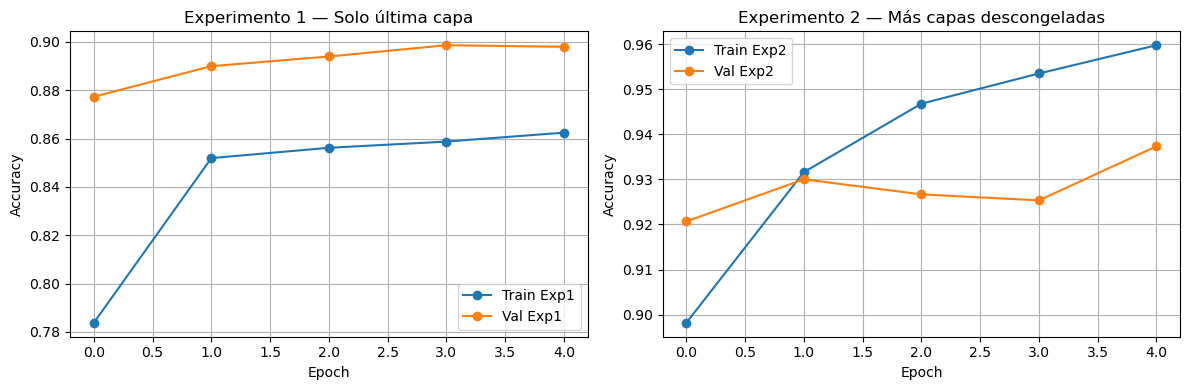

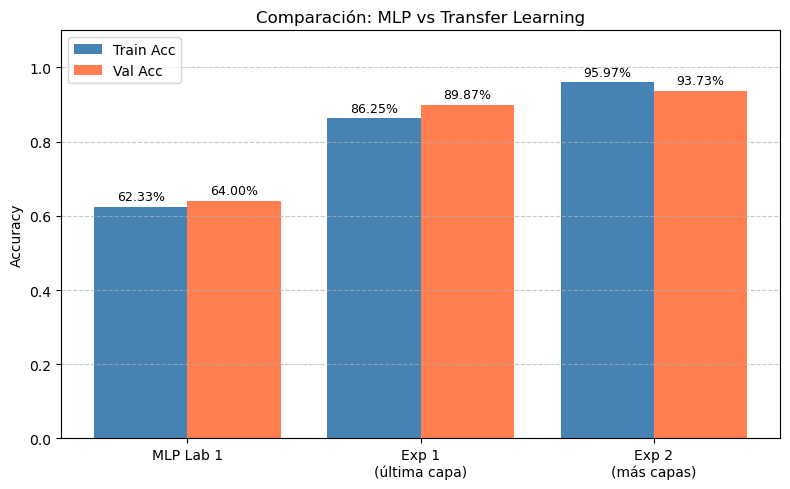


╔══════════════════════════════════════════════════════════════════╗
║              ANÁLISIS COMPARATIVO — QUIZ 2                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. ACCURACIES                                                   ║
║     MLP Lab 1      → Train: 62.33% | Val: 64.00%               ║
║     Exp 1 (TL)     → Train: 86.25% | Val: 89.87%               ║
║     Exp 2 (TL)     → Train: 95.97% | Val: 93.73%               ║
║                                                                  ║
║  2. TRANSFER LEARNING vs MLP                                     ║
║     El MLP procesaba imágenes en escala de grises (1 canal)     ║
║     aplanadas (22,500 features), sin aprovechar estructura      ║
║     espacial. Requirió 75 epochs para alcanzar 64% val acc.     ║
║     Transfer learning con VGG16 preentrenado en ImageNet        ║
║     superó al MLP en solo 5 epochs (+25.87

In [16]:
import matplotlib.pyplot as plt

# ── Gráficas de curvas de aprendizaje ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_accs_exp1, label='Train Exp1', marker='o')
ax1.plot(val_accs_exp1,   label='Val Exp1',   marker='o')
ax1.set_title('Experimento 1 — Solo última capa')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs_exp2, label='Train Exp2', marker='o')
ax2.plot(val_accs_exp2,   label='Val Exp2',   marker='o')
ax2.set_title('Experimento 2 — Más capas descongeladas')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('curvas_experimentos.png', dpi=150)
plt.show()

# ── Gráfica comparativa de los 3 modelos ───────────────────────────
modelos    = ['MLP Lab 1', 'Exp 1\n(última capa)', 'Exp 2\n(más capas)']
train_accs = [0.6233,      0.8625,                  0.9597]
val_accs   = [0.6400,      0.8987,                  0.9373]

x = range(len(modelos))
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - 0.2 for i in x], train_accs, width=0.4, label='Train Acc', color='steelblue')
bars2 = ax.bar([i + 0.2 for i in x], val_accs,   width=0.4, label='Val Acc',   color='coral')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2%}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(modelos)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Comparación: MLP vs Transfer Learning')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150)
plt.show()

# ── Análisis comparativo (punto 5 del enunciado) ───────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║              ANÁLISIS COMPARATIVO — QUIZ 2                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. ACCURACIES                                                   ║
║     MLP Lab 1      → Train: 62.33% | Val: 64.00%               ║
║     Exp 1 (TL)     → Train: 86.25% | Val: 89.87%               ║
║     Exp 2 (TL)     → Train: 95.97% | Val: 93.73%               ║
║                                                                  ║
║  2. TRANSFER LEARNING vs MLP                                     ║
║     El MLP procesaba imágenes en escala de grises (1 canal)     ║
║     aplanadas (22,500 features), sin aprovechar estructura      ║
║     espacial. Requirió 75 epochs para alcanzar 64% val acc.     ║
║     Transfer learning con VGG16 preentrenado en ImageNet        ║
║     superó al MLP en solo 5 epochs (+25.87% val acc en Exp1)   ║
║     porque reutiliza features visuales aprendidas en millones   ║
║     de imágenes (bordes, texturas, formas).                     ║
║                                                                  ║
║  3. EXP 1 vs EXP 2 (última capa vs más capas)                  ║
║     Exp 1 entrenó solo 3,006 params (capa final), logrando     ║
║     89.87% val acc — las features de VGG ya son suficientes.   ║
║     Exp 2 desbloqueó las últimas conv layers (~7.6M params)    ║
║     con lr=1e-4, subiendo a 93.73% val acc (+3.86%).           ║
║     La diferencia train/val en Exp2 (95.97% vs 93.73%)         ║
║     indica leve overfitting — más epochs podría empeorarlo.    ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")